In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
from dotenv import load_dotenv
from pymatgen.core import Element
from scipy import stats
from mp_api.client import MPRester
from pymatgen.core import Element

In [3]:
load_dotenv()
API_KEY = os.getenv("MY_API_KEY")

In [4]:
with MPRester(API_KEY) as m:
   docs = m.materials.summary.search(
    num_elements=2,
    fields=[
        "material_id", 
        "formula_pretty",
        "elements", 
        "nelements",
        "formation_energy_per_atom",
        "energy_above_hull",
        "is_stable",
        "symmetry",
        "composition_reduced",
        "structure"

        ]
   )

print(f"Found {len(docs)} entries for Fe-based alloys.")
print(docs[0])

Retrieving SummaryDoc documents:   0%|          | 0/20765 [00:00<?, ?it/s]

Found 20765 entries for Fe-based alloys.
MPDataDoc<_DictLikeAccess>
elements=[Element Ac, Element Mg],
nelements=2,
composition_reduced=Composition('Ac2 Mg1'),
formula_pretty='Ac2Mg',
symmetry=SymmetryData(crystal_system=<CrystalSystem.ortho: 'Orthorhombic'>, symbol='Cmcm', hall=None, number=63, point_group='mmm', symprec=0.1, angle_tolerance=5.0, version='2.5.0'),
material_id=MPID(mp-1183085),
structure=Structure Summary
Lattice
    abc : 9.578803530984482 9.578803530984482 6.02795032
 angles : 90.0 90.0 154.81317354188255
 volume : 235.37724069558234
      A : np.float64(2.08847657) np.float64(-9.34835508) np.float64(0.0)
      B : np.float64(2.08847657) np.float64(9.34835508) np.float64(-0.0)
      C : np.float64(0.0) np.float64(-0.0) np.float64(6.02795032)
    pbc : True True True
PeriodicSite: Ac (2.088, 5.127, 1.507) [0.2258, 0.7742, 0.25]
PeriodicSite: Ac (2.088, -7.79, 1.507) [0.9167, 0.08332, 0.25]
PeriodicSite: Ac (2.088, -5.127, 4.521) [0.7742, 0.2258, 0.75]
PeriodicSite: Ac

In [5]:
rows = []
for d in docs:
    rows.append({
        "material_id": d.material_id,
        "formula": d.formula_pretty,
        "elements": [str(el) for el in d.elements],
        "nelements": d.nelements,
        "formation_energy_per_atom": d.formation_energy_per_atom,
        "energy_above_hull": d.energy_above_hull,
        "is_stable": d.is_stable,
        "symmetry": d.symmetry,
        "composition_reduced": d.composition_reduced.as_dict() if d.composition_reduced else None,
        "structure": d.structure.as_dict() if d.structure else None
    })
    
df = pd.DataFrame(rows)
print(f"DataFrame created with {len(df)} rows and {len(df.columns)} columns.")
print(df.head())

DataFrame created with 20765 rows and 10 columns.
  material_id formula  elements  nelements  formation_energy_per_atom  \
0  mp-1183085   Ac2Mg  [Ac, Mg]          2                  -0.006879   
1  mp-1183089   Ac2Mg  [Ac, Mg]          2                  -0.019751   
2   mp-985286   Ac2Mg  [Ac, Mg]          2                  -0.006999   
3    mp-11107   Ac2O3   [Ac, O]          2                  -3.737668   
4    mp-32800   Ac2S3   [Ac, S]          2                  -2.493064   

   energy_above_hull  is_stable  \
0           0.033050      False   
1           0.020178      False   
2           0.032931      False   
3           0.000000       True   
4           0.000000       True   

                                            symmetry     composition_reduced  \
0  crystal_system=<CrystalSystem.ortho: 'Orthorho...  {'Ac': 2.0, 'Mg': 1.0}   
1  crystal_system=<CrystalSystem.mono: 'Monoclini...  {'Ac': 2.0, 'Mg': 1.0}   
2  crystal_system=<CrystalSystem.tet: 'Tetragonal...  {'Ac':

In [6]:
def is_metal_pair(elements):
    return all(Element(el).is_metal for el in elements)
    

df=df[df["elements"].apply(is_metal_pair)].copy()
print(f"Filtered to {len(df)} binary metal alloys.")

Filtered to 9360 binary metal alloys.


In [7]:
df["pair"]=df["elements"].apply(lambda x: "-".join(sorted(x)))
pair_df = df.groupby("pair").agg(
    min_e_above_hull=("energy_above_hull", "min"),
    min_formation_energy=("formation_energy_per_atom", "min"),
    n_entries=("material_id", "count"),
    any_stable=("is_stable", "max")
).reset_index()
print("Total alloy pairs:", len(pair_df))
pair_df

Total alloy pairs: 1867


,pair,min_e_above_hull,min_formation_energy,n_entries,any_stable
0,Ac-Ag,0.000000,-0.271157,4,True
1,Ac-Al,0.000000,-0.408916,1,True
2,Ac-Au,0.000000,-0.771292,2,True
3,Ac-Ba,0.104439,0.104439,3,False
4,Ac-Ca,0.027833,0.027833,2,False
...,...,...,...,...,...
1862,Y-Zn,0.000000,-0.400875,13,True
1863,Y-Zr,0.112601,0.112601,1,False
1864,Yb-Zn,0.000000,-0.448140,3,True
1865,Yb-Zr,0.019923,0.019923,2,False


In [8]:
#Features

def get_features(pair):
    A,B=pair.split("-")
    el1,el2=Element(A),Element(B)

    return {
        "pair":pair,

        #atomic number
        "Z_avg":(el1.Z+el2.Z)/2,
        "Z_diff":abs(el1.Z-el2.Z),
        #atomic radius
        "r_avg":(el1.atomic_radius+el2.atomic_radius)/2,
        "r_diff":abs(el1.atomic_radius-el2.atomic_radius),
        #electronegativity
        "EN_avg":(el1.X+el2.X)/2,
        "EN_diff":abs(el1.X-el2.X),
        # periodic trends
        "same_group": int(el1.group==el2.group),
        "same_block": int(el1.block==el2.block),
    }

features_df = pd.DataFrame([get_features(pair) for pair in pair_df["pair"]])
features_df

,pair,Z_avg,Z_diff,r_avg,r_diff,EN_avg,EN_diff,same_group,same_block
0,Ac-Ag,68.0,42,1.775,0.35,1.515,0.83,0,0
1,Ac-Al,51.0,76,1.600,0.70,1.355,0.51,0,0
2,Ac-Au,84.0,10,1.650,0.60,1.820,1.44,0,0
3,Ac-Ba,72.5,33,2.050,0.20,0.995,0.21,0,0
4,Ac-Ca,54.5,69,1.875,0.15,1.050,0.10,0,0
...,...,...,...,...,...,...,...,...,...
1862,Y-Zn,34.5,9,1.575,0.45,1.435,0.43,0,1
1863,Y-Zr,39.5,1,1.675,0.25,1.275,0.11,0,1
1864,Yb-Zn,50.0,40,1.550,0.40,1.375,0.55,0,0
1865,Yb-Zr,55.0,30,1.650,0.20,1.215,0.23,0,0


In [9]:
final_df = pair_df.merge(features_df, on="pair")
exclude = {"Ac", "Pm", "Np", "Pu", "Pa", "Tc", "Po", "At", "Ra", "Th", "U"}
mask = final_df["pair"].apply(
    lambda p: not any(el in exclude for el in p.split("-"))
)
final_df = final_df[mask].copy()
print(f"Pairs after filtering: {len(final_df)}")
final_df.head()

Pairs after filtering: 1482


,pair,min_e_above_hull,min_formation_energy,n_entries,any_stable,Z_avg,Z_diff,r_avg,r_diff,EN_avg,EN_diff,same_group,same_block
45,Ag-Al,0.000000,-0.072475,6,True,30.0,34,1.425,0.35,1.770,0.32,0,0
46,Ag-Au,0.000000,-0.064885,8,True,63.0,32,1.475,0.25,2.235,0.61,1,1
47,Ag-Ba,0.000000,-0.288193,5,True,51.5,9,1.875,0.55,1.410,1.04,0,0
48,Ag-Be,0.029721,0.029721,4,False,25.5,43,1.325,0.55,1.750,0.36,0,0
49,Ag-Bi,0.146643,0.146643,1,False,65.0,36,1.600,0.00,1.975,0.09,0,0


In [10]:
final_df["radius_mismatch_pct"] = final_df["r_diff"] / final_df["r_avg"]
final_df.groupby("any_stable")["radius_mismatch_pct"].mean()

any_stable
False    0.176541
True     0.184230
Name: radius_mismatch_pct, dtype: float64

In [11]:
final_df.groupby("any_stable")["EN_diff"].mean()

any_stable
False    0.370386
True     0.649988
Name: EN_diff, dtype: float64

In [12]:
from sklearn.ensemble import RandomForestClassifier

X = final_df[["r_diff", "EN_diff", "Z_diff"]].dropna()
y = final_df.loc[X.index, "any_stable"]

model = RandomForestClassifier()
model.fit(X, y)

print(model.feature_importances_)

[0.21065303 0.49031094 0.29903602]


In [13]:
final_df.describe()

,min_e_above_hull,min_formation_energy,n_entries,Z_avg,Z_diff,r_avg,r_diff,EN_avg,EN_diff,same_group,same_block,radius_mismatch_pct
count,1482.000000,1482.000000,1482.000000,1482.000000,1482.000000,1482.000000,1482.000000,1482.000000,1482.000000,1482.000000,1482.000000,1482.000000
mean,0.117977,-0.114929,5.609987,48.514170,26.384615,1.603492,0.297874,1.554214,0.532638,0.109312,0.331984,0.181003
std,0.248789,0.461074,7.513956,16.038772,18.689090,0.202995,0.247193,0.324351,0.380907,0.312135,0.471084,0.141300
min,0.000000,-1.464130,1.000000,3.500000,1.000000,1.150000,0.000000,0.805000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,-0.381609,2.000000,37.000000,10.000000,1.450000,0.100000,1.315000,0.220000,0.000000,0.000000,0.064516
50%,0.000000,-0.075801,4.000000,49.000000,23.000000,1.575000,0.250000,1.560000,0.470000,0.000000,0.000000,0.153846
75%,0.108480,0.107882,7.000000,60.000000,40.000000,1.743750,0.450000,1.765000,0.790000,0.000000,1.000000,0.276923
max,1.557705,1.557705,88.000000,82.500000,80.000000,2.475000,1.350000,2.450000,1.750000,1.000000,1.000000,0.707692


In [14]:
final_df.groupby("any_stable")[[
    "r_diff", "EN_diff", "Z_diff"
]].mean()

,r_diff,EN_diff,Z_diff
any_stable,,,
False,0.304743,0.370386,25.699357
True,0.292907,0.649988,26.880233


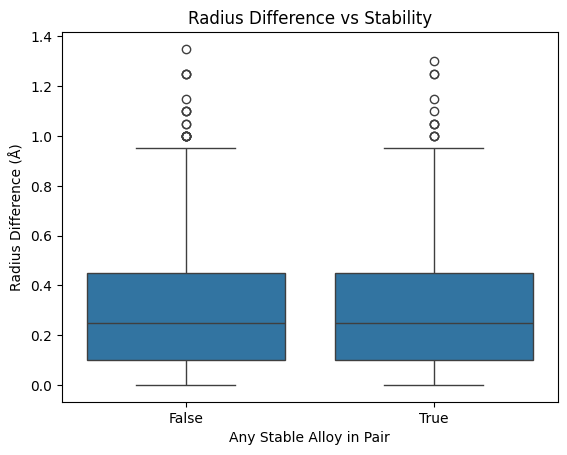

In [15]:
sns.boxplot(x="any_stable", y="r_diff", data=final_df)
plt.title("Radius Difference vs Stability")
plt.xlabel("Any Stable Alloy in Pair")
plt.ylabel("Radius Difference (Å)")
plt.show()

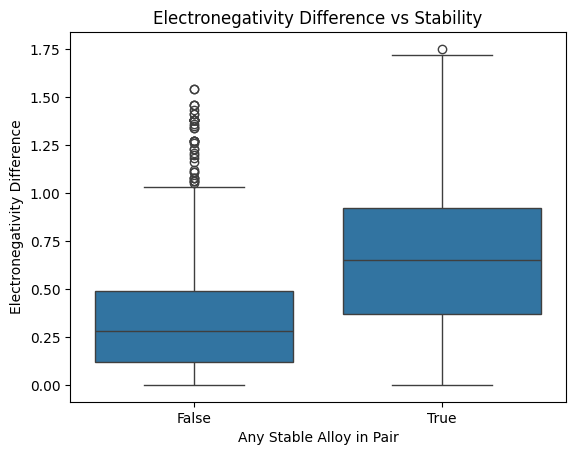

In [16]:
sns.boxplot(x="any_stable", y="EN_diff", data=final_df)
plt.title("Electronegativity Difference vs Stability")
plt.xlabel("Any Stable Alloy in Pair")
plt.ylabel("Electronegativity Difference")
plt.show()

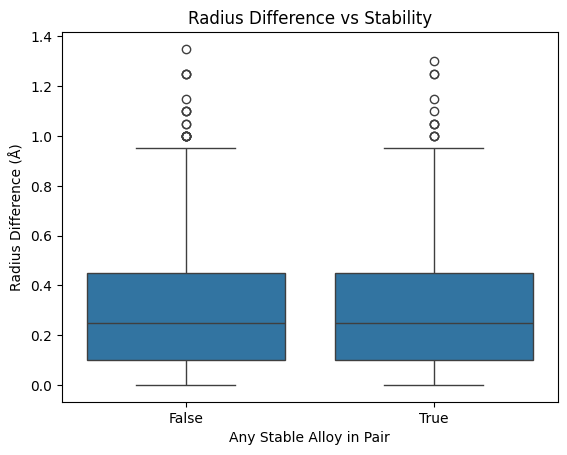

In [17]:
sns.boxplot(x="any_stable", y="r_diff", data=final_df)
plt.title("Radius Difference vs Stability")
plt.xlabel("Any Stable Alloy in Pair")
plt.ylabel("Radius Difference (Å)")
plt.show()

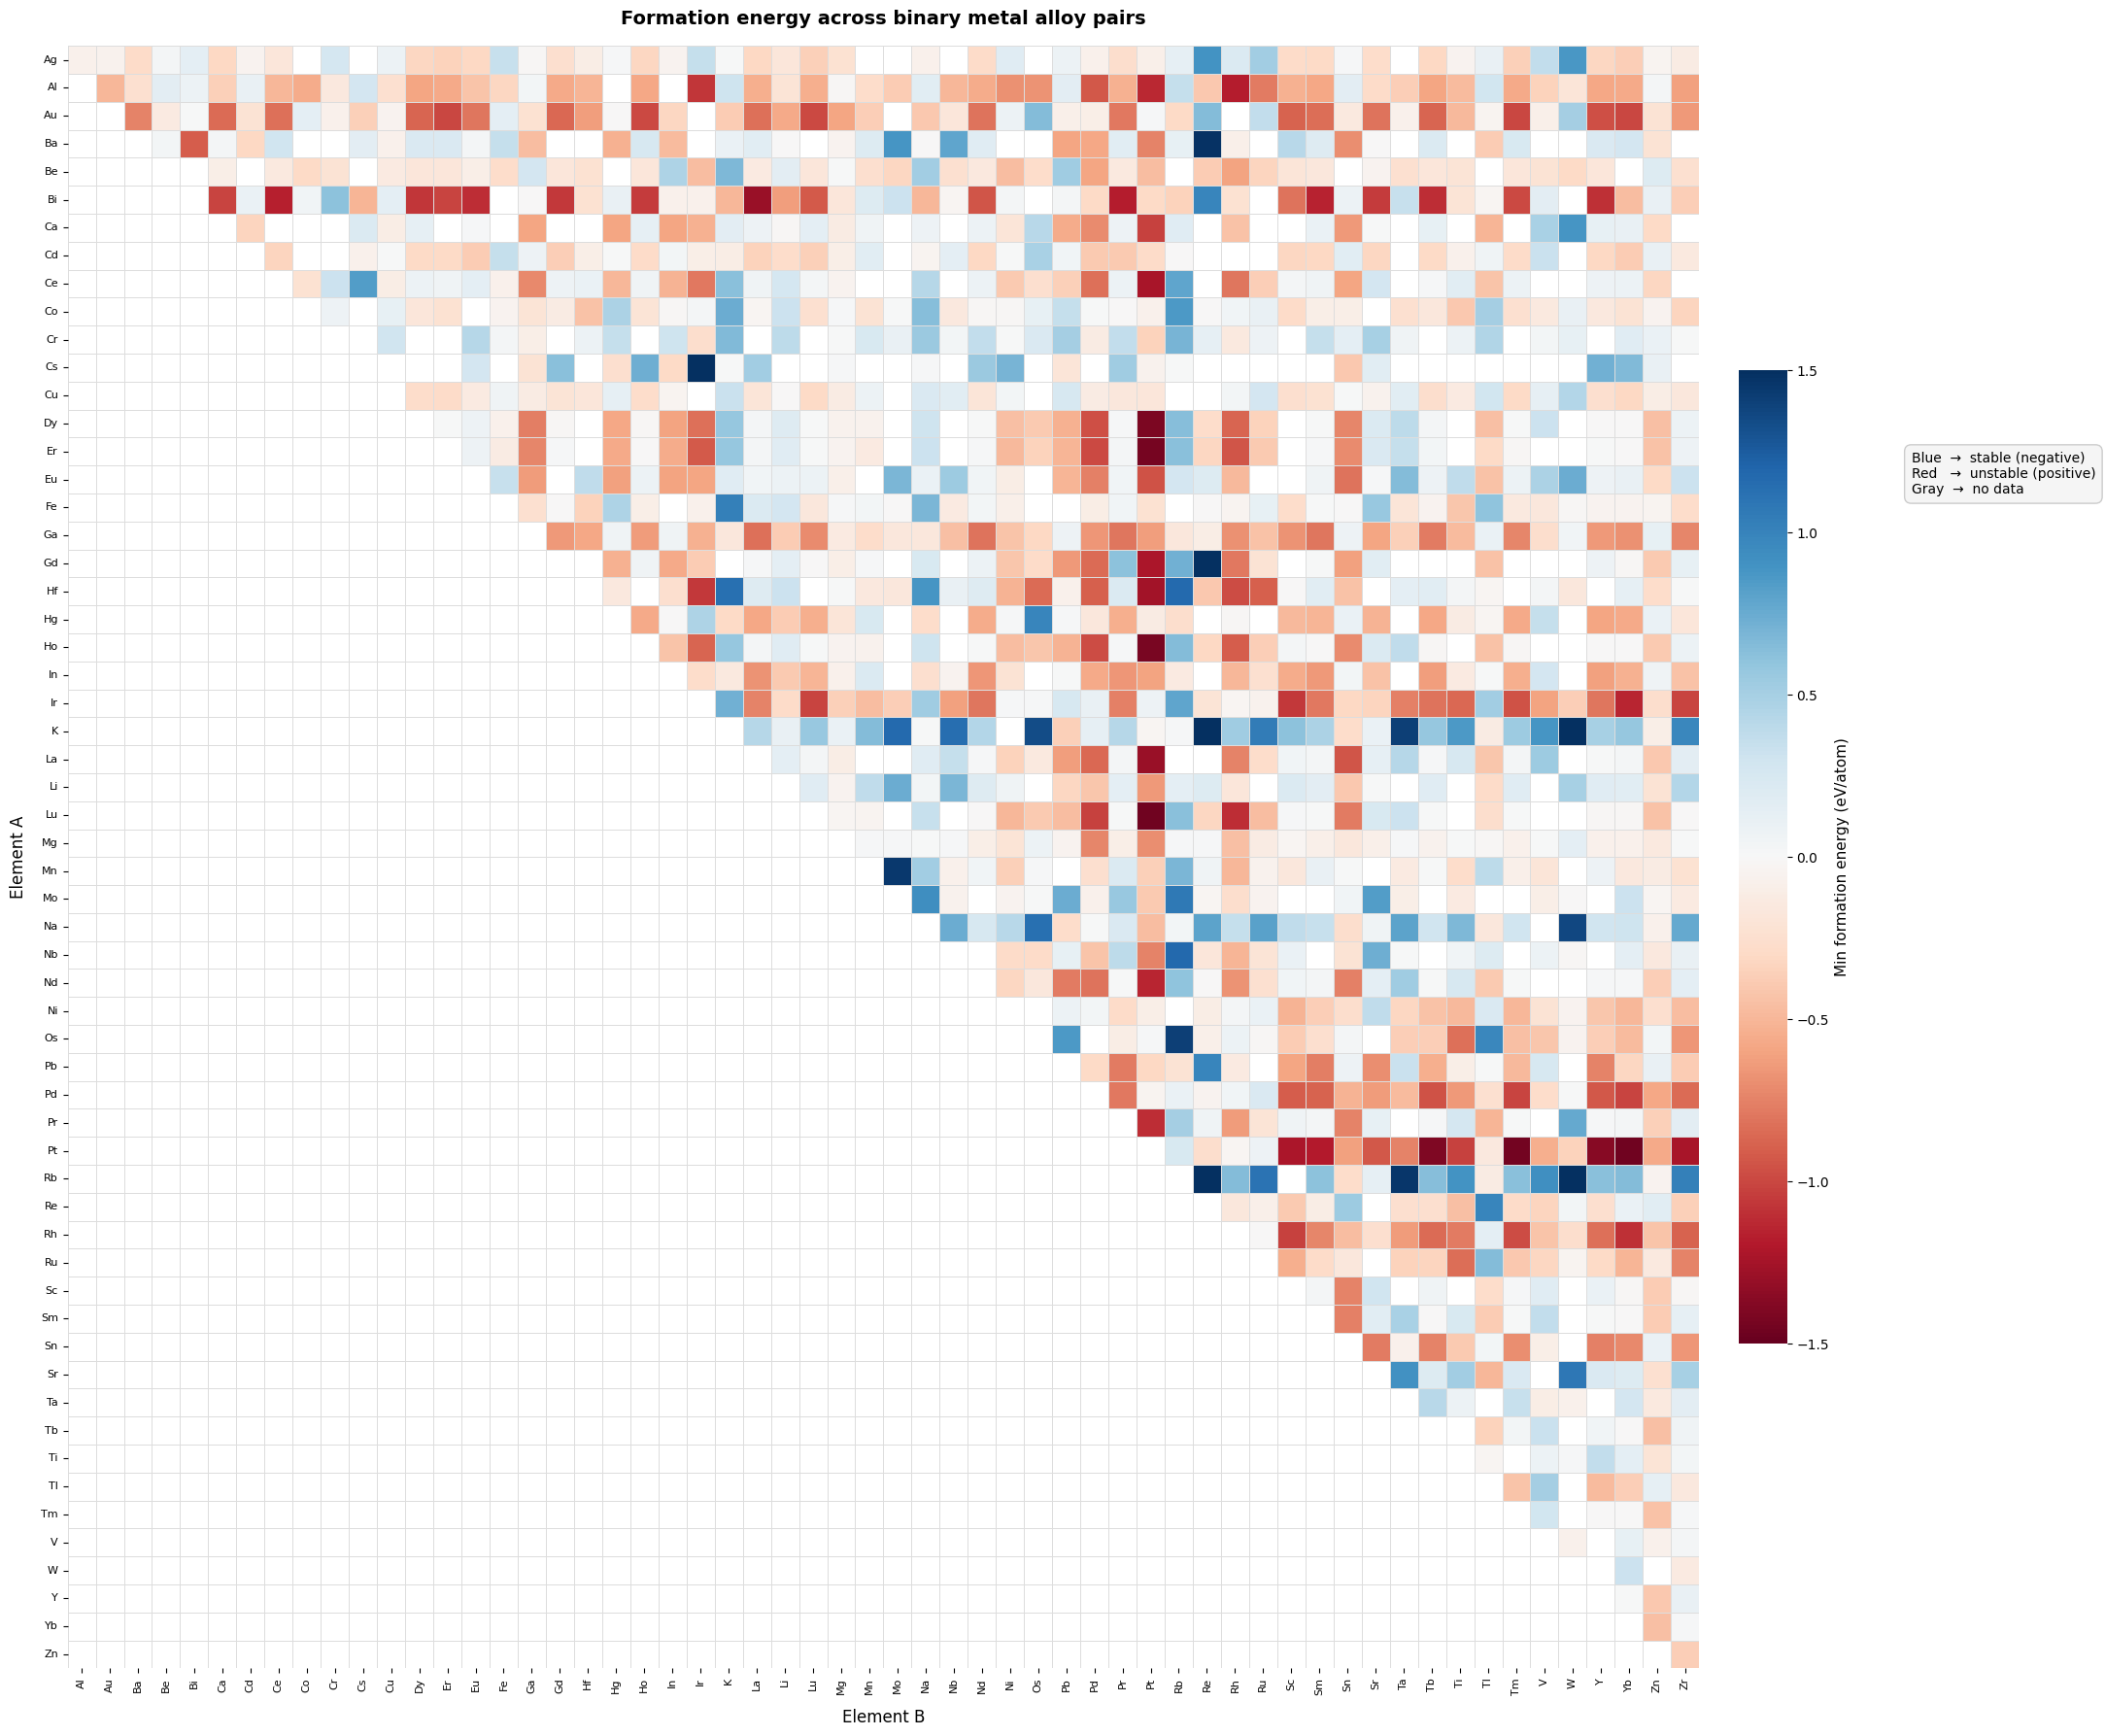

In [18]:

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#cccccc",
    "grid.color": "#eeeeee",
})

pivot = final_df.copy()
pivot[["el1", "el2"]] = pivot["pair"].str.split("-", expand=True)
matrix = pivot.pivot_table(
    index="el1", columns="el2",
    values="min_formation_energy", aggfunc="min"
)

fig, ax = plt.subplots(figsize=(22, 18))
hm = sns.heatmap(
    matrix,
    cmap="RdBu",
    center=0,
    vmin=-1.5, vmax=1.5,
    linewidths=0.4,
    linecolor="#dddddd",
    ax=ax,
    cbar_kws={
        "label": "Min formation energy (eV/atom)",
        "shrink": 0.6,
        "pad": 0.02,
    }
)

hm.collections[0].colorbar.ax.tick_params(labelsize=10)
hm.collections[0].colorbar.set_label("Min formation energy (eV/atom)", fontsize=11)

ax.text(
    1.13, 0.75,
    "Blue  →  stable (negative)\nRed   →  unstable (positive)\nGray  →  no data",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5", edgecolor="#cccccc")
)

ax.set_title("Formation energy across binary metal alloy pairs", pad=16)
ax.set_xlabel("Element B", labelpad=10)
ax.set_ylabel("Element A", labelpad=10)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

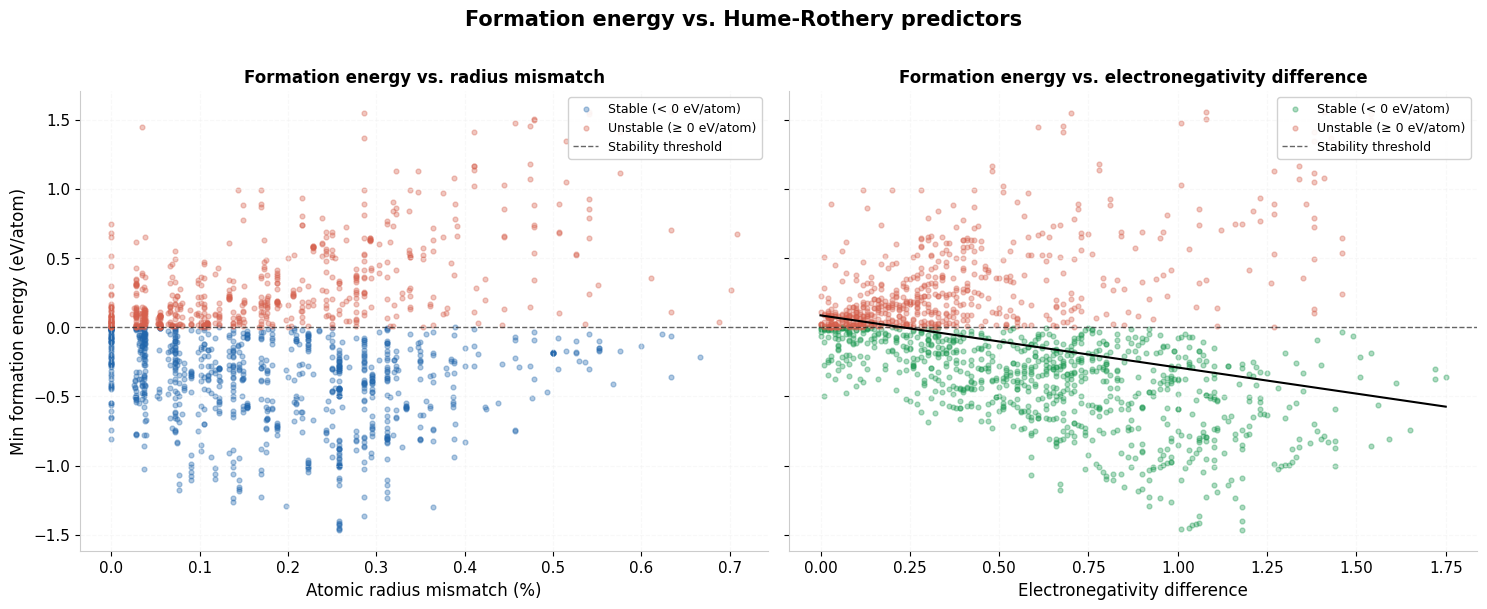

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
fig.suptitle("Formation energy vs. Hume-Rothery predictors", fontsize=15, fontweight="bold", y=1.01)

stable_mask = final_df["min_formation_energy"] < 0

for ax, xcol, color_s, color_u, xlabel, title in [
    (axes[0], "radius_mismatch_pct", "#2166ac", "#d6604d",
     "Atomic radius mismatch (%)", "Formation energy vs. radius mismatch"),
    (axes[1], "EN_diff", "#1a9850", "#d6604d",
     "Electronegativity difference", "Formation energy vs. electronegativity difference"),
]:
    ax.scatter(
        final_df.loc[stable_mask, xcol],
        final_df.loc[stable_mask, "min_formation_energy"],
        alpha=0.35, s=12, color=color_s, label="Stable (< 0 eV/atom)"
    )
    ax.scatter(
        final_df.loc[~stable_mask, xcol],
        final_df.loc[~stable_mask, "min_formation_energy"],
        alpha=0.35, s=12, color=color_u, label="Unstable (≥ 0 eV/atom)"
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6, label="Stability threshold")
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9, loc="upper right", framealpha=0.9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
# regression line
m, b = np.polyfit(final_df["EN_diff"], final_df["min_formation_energy"], 1)
x_line = np.linspace(final_df["EN_diff"].min(), final_df["EN_diff"].max(), 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.5, label=f"Trend (slope={m:.2f})")

axes[0].set_ylabel("Min formation energy (eV/atom)")
plt.tight_layout()
plt.savefig("scatter.png", dpi=150, bbox_inches="tight")
plt.show()

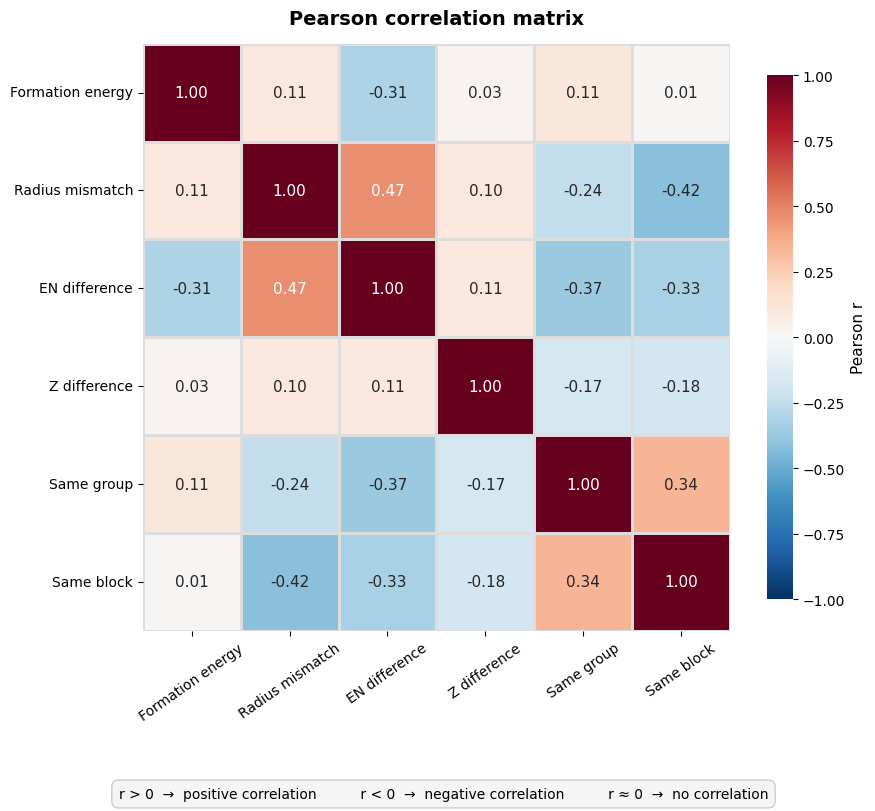

In [20]:
corr_cols = [
    "min_formation_energy", "radius_mismatch_pct",
    "EN_diff", "Z_diff", "same_group", "same_block"
]
labels = [
    "Formation energy", "Radius mismatch",
    "EN difference", "Z difference", "Same group", "Same block"
]
corr = final_df[corr_cols].corr()
corr.index = labels
corr.columns = labels

fig, ax = plt.subplots(figsize=(9, 8))

hm2 = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.8,
    linecolor="#dddddd",
    ax=ax,
    cbar_kws={
        "label": "Pearson r",
        "shrink": 0.75,
    },
    annot_kws={"size": 11}
)

hm2.collections[0].colorbar.set_label("Pearson r", fontsize=11)
hm2.collections[0].colorbar.ax.tick_params(labelsize=10)

ax.set_title("Pearson correlation matrix", pad=14)
ax.tick_params(axis="x", rotation=35, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)

fig.text(
    0.5, -0.04,
    "r > 0  →  positive correlation          r < 0  →  negative correlation          r ≈ 0  →  no correlation",
    ha="center", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5", edgecolor="#cccccc")
)

plt.tight_layout()
plt.savefig("correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# T-test: are stable and unstable alloys actually different in EN_diff?
stable = final_df.loc[final_df["any_stable"] == True, "EN_diff"]
unstable = final_df.loc[final_df["any_stable"] == False, "EN_diff"]
t_stat, p_val = stats.ttest_ind(stable, unstable)
print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")

# Linear regression: how well does EN_diff predict formation energy?
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(
    final_df["EN_diff"], final_df["min_formation_energy"]
)
print(f"R²: {r_value**2:.3f}, slope: {slope:.3f}, p-value: {p_value:.4f}")

T-statistic: 14.958, p-value: 0.0000
R²: 0.097, slope: -0.377, p-value: 0.0000


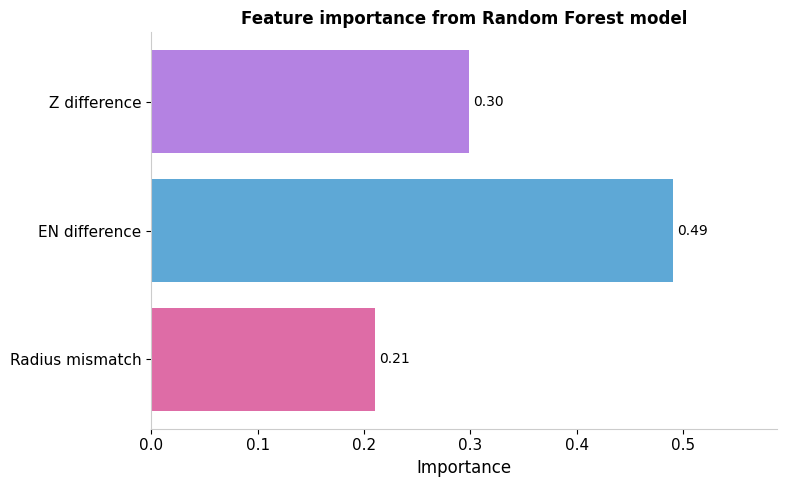

In [22]:
features = ["Radius mismatch", "EN difference", "Z difference"]
importance = model.feature_importances_

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(features, importance, color=["#d12e80", "#1a83c5", "#944dd6"], alpha=0.7)
ax.set_title("Feature importance from Random Forest model", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance")
ax.set_xlim(0, max(importance)*1.2)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

/var/folders/7b/l4bd8yf50b9_zt4ms77_l52w0000gn/T/ipykernel_42933/522485273.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Unstable", "Stable"])
/var/folders/7b/l4bd8yf50b9_zt4ms77_l52w0000gn/T/ipykernel_42933/522485273.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Unstable", "Stable"])


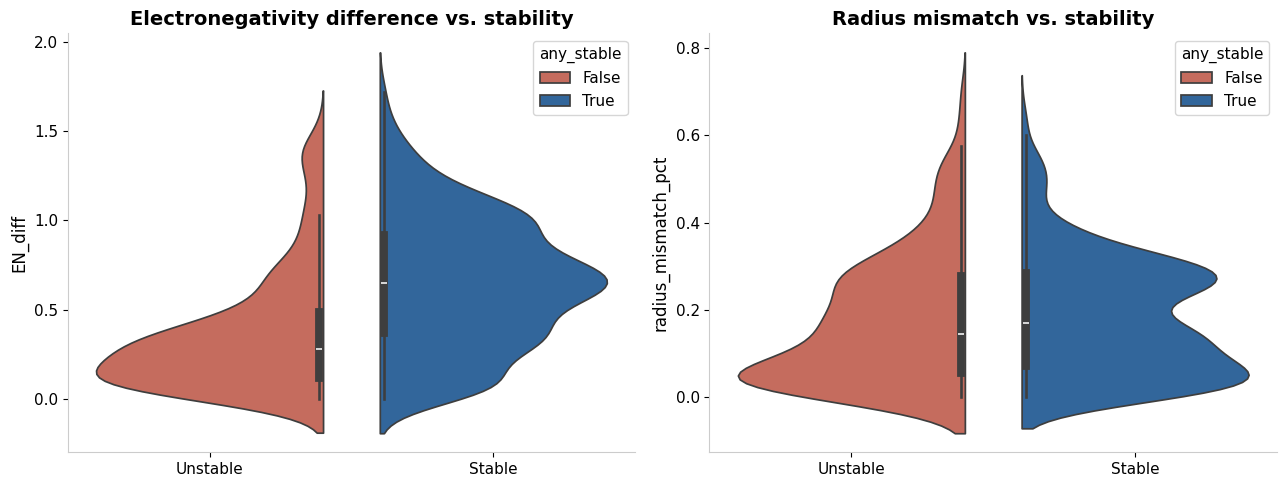

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "EN_diff", "Electronegativity difference vs. stability"),
    (axes[1], "radius_mismatch_pct", "Radius mismatch vs. stability"),
]:
    sns.violinplot(
        x="any_stable", y=col, data=final_df,
        palette={True: "#2166ac", False: "#d6604d"},
        hue="any_stable", split=True,
        inner="box", ax=ax
    )
    ax.set_xticklabels(["Unstable", "Stable"])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [42]:
from mp_api.client import MPRester

structure_map = {}

with MPRester(API_KEY) as mpr:
    element_docs = mpr.summary.search(
        num_elements=1,
        fields=["formula_pretty", "symmetry", "energy_above_hull"]
    )

for doc in element_docs:
    formula = doc.formula_pretty
    e_hull = doc.energy_above_hull

    # Safely extract crystal system
    try:
        cs = doc.symmetry.crystal_system.value
    except:
        cs = None

    # Keep only ground state per element
    if formula not in structure_map:
        structure_map[formula] = {"crystal_system": cs, "e_hull": e_hull}
    else:
        if e_hull < structure_map[formula]["e_hull"]:
            structure_map[formula] = {"crystal_system": cs, "e_hull": e_hull}

# Flatten to element → crystal system
structure_map = {el: data["crystal_system"] for el, data in structure_map.items()}

# Check results
none_count = sum(1 for v in structure_map.values() if v is None)
valid_count = sum(1 for v in structure_map.values() if v is not None)
print(f"Valid: {valid_count}, None: {none_count}")
print("\nSample:", dict(list(structure_map.items())[:15]))

/var/folders/7b/l4bd8yf50b9_zt4ms77_l52w0000gn/T/ipykernel_42933/99666882.py:6: DeprecationWarning: Accessing summary data through MPRester.summary is deprecated. Please use MPRester.materials.summary instead.
  element_docs = mpr.summary.search(


Retrieving SummaryDoc documents:   0%|          | 0/834 [00:00<?, ?it/s]

Valid: 89, None: 0

Sample: {'Ac': 'Hexagonal', 'Ag': 'Hexagonal', 'Al': 'Cubic', 'Ar': 'Cubic', 'As': 'Orthorhombic', 'Au': 'Cubic', 'B': 'Trigonal', 'Ba': 'Cubic', 'Be': 'Hexagonal', 'Bi': 'Trigonal', 'Br': 'Orthorhombic', 'C': 'Monoclinic', 'Ca': 'Cubic', 'Cd': 'Hexagonal', 'Ce': 'Cubic'}


In [43]:
def get_pair_structure(pair):
    parts = pair.split("-")
    if len(parts) != 2:
        return None
    a, b = parts
    s1 = structure_map.get(a)
    s2 = structure_map.get(b)
    if s1 and s2:
        return s1
    return None

final_df["crystal_structure"] = final_df["pair"].apply(get_pair_structure)

print(final_df["crystal_structure"].value_counts())
print(f"\nUnclassified pairs: {final_df['crystal_structure'].isna().sum()} out of {len(final_df)}")
print(f"Total pairs: {len(final_df)}")

crystal_structure
Cubic           656
Hexagonal       534
Trigonal        171
Orthorhombic     74
Tetragonal       30
Monoclinic       17
Name: count, dtype: int64

Unclassified pairs: 0 out of 1482
Total pairs: 1482


Crystal systems included ['Cubic', 'Hexagonal', 'Trigonal', 'Orthorhombic', 'Tetragonal']


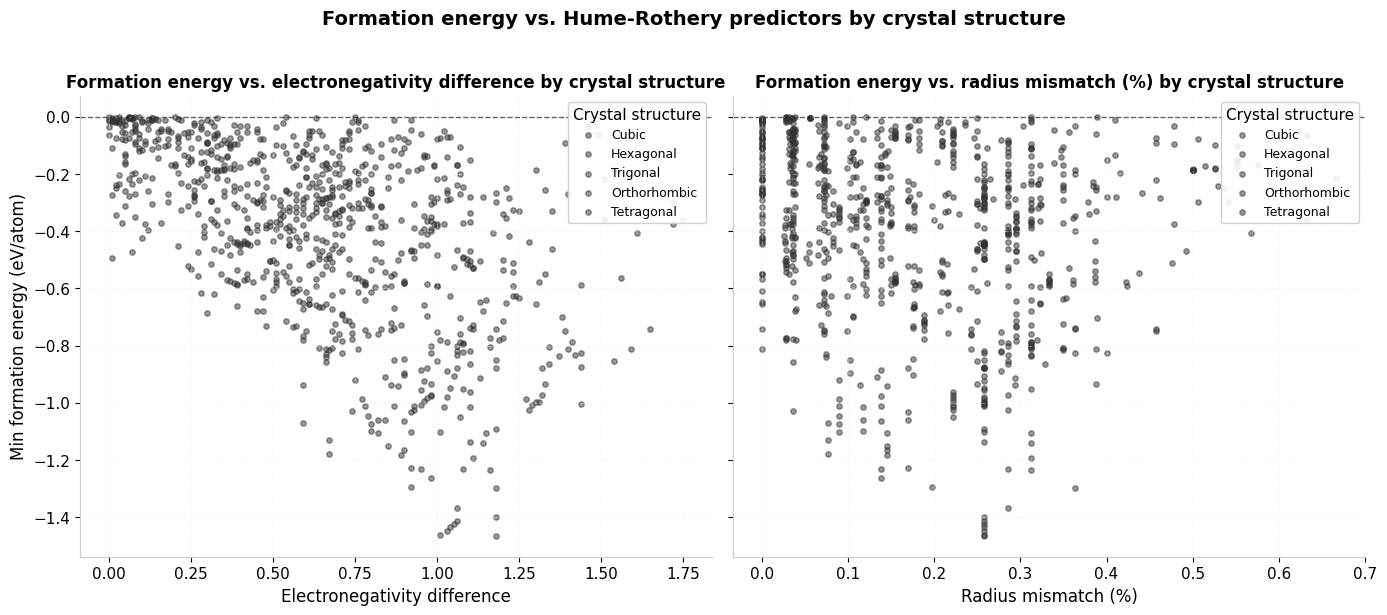

In [45]:
plot_df = final_df.dropna(subset=["crystal_structure"])

counts = plot_df["crystal_structure"].value_counts()
valid_structures = counts[counts > 20].index.tolist()
plot_df = plot_df[plot_df["crystal_structure"].isin(valid_structures)].copy()

print("Crystal systems included",valid_structures)
# color
palette = {
    "cubic": "#1f77b4",
    "hexagonal": "#ff7f0e",
    "tetragonal": "#2ca02c",
    "orthorhombic": "#d62728",
    "monoclinic": "#9467bd",
    "triclinic": "#8c564b"
}
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Formation energy vs. Hume-Rothery predictors by crystal structure",
                fontsize=14, fontweight="bold", y=1.02
)
for ax, xcol, xlabel in [
    (axes[0], "EN_diff", "Electronegativity difference"),
    (axes[1], "radius_mismatch_pct", "Radius mismatch (%)"),
]:
    
    for structure in valid_structures:
        subset = plot_df[plot_df["crystal_structure"] == structure]
        stable_mask = subset["min_formation_energy"] < 0
        ax.scatter(
            subset.loc[stable_mask, xcol],
            subset.loc[stable_mask, "min_formation_energy"],
            alpha=0.5, s=15, color=palette.get(structure, "#333333"),
            label=structure
        )
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_title(f"Formation energy vs. {xlabel.lower()} by crystal structure", fontsize=12)
    ax.legend(title="Crystal structure", fontsize=9, loc="upper right", framealpha=0.9)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Min formation energy (eV/atom)")
plt.tight_layout()
plt.savefig("structure_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
   

In [46]:
corr_results = []

for structure in valid_structures:
    subset = plot_df[plot_df["crystal_structure"] == structure]
    if len(subset) < 10:
        continue
    r_en, p_en = stats.pearsonr(subset["EN_diff"], subset["min_formation_energy"])
    r_r, p_r = stats.pearsonr(subset["radius_mismatch_pct"], subset["min_formation_energy"])
    corr_results.append({
        "crystal_structure": structure,
        "r_EN_diff": r_en,
        "p_EN_diff": p_en,
        "r_radius_mismatch": r_r,
        "p_radius_mismatch": p_r
    })
corr_table = pd.DataFrame(corr_results).sort_values("r_EN_diff", key=abs, ascending=False)
print(corr_table[["crystal_structure", "r_EN_diff", "p_EN_diff", "r_radius_mismatch", "p_radius_mismatch"]])

  crystal_structure  r_EN_diff     p_EN_diff  r_radius_mismatch  \
2          Trigonal  -0.596963  6.870749e-18          -0.188675   
1         Hexagonal  -0.368674  1.231418e-18           0.036015   
0             Cubic  -0.368316  1.659705e-22           0.018092   
3      Orthorhombic   0.279943  1.570622e-02           0.391386   
4        Tetragonal  -0.063381  7.393352e-01           0.128082   

   p_radius_mismatch  
2           0.013459  
1           0.406213  
0           0.643693  
3           0.000564  
4           0.499986  
